In [17]:
from langgraph.graph import END,START,StateGraph
from typing import TypedDict , Literal , Annotated
from langchain_huggingface import ChatHuggingFace ,HuggingFaceEndpoint
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel,Field
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [7]:
llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation")

model = ChatHuggingFace(llm=llm)

In [8]:
class Tweet_evaluation(BaseModel):
    evaluation : Literal["approved","need_improvment"] = Field(description="final evaluation")
    feedback : str = Field(description="feedback of the tweet")


In [9]:
parser_evaluation = PydanticOutputParser(pydantic_object=Tweet_evaluation)

In [10]:
promt_evaluation = PromptTemplate(
        template="""
you are sentiment classifier .
return ONLY valide JSON
{format_instrucations}
tweet:{tweet}
Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses """,
input_variables=["tweet"],
partial_variables={"format_instrucations":parser_evaluation.get_format_instructions()}
)

In [18]:
class Project_state(TypedDict):
    topic : str
    tweet : str
    evaluation : Literal["approved","need_improvment"]
    feedback : str
    iteration : int
    max_interation : int

    tweet_history :  Annotated[list[str],operator.add]
    feedback_history : Annotated[list[str],operator.add]
    

In [19]:
def create_tweet(state:Project_state):
    topic = state["topic"]
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{topic}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    tweet = model.invoke(messages)
    return {"tweet":tweet}


In [39]:
def evaluate_tweet(state:Project_state):
    tweet = state["tweet"]
    chain = promt_evaluation | model | parser_evaluation
    response = chain.invoke({"tweet":tweet})

    return {"evaluation":response.evaluation,"feedback":response.feedback,"feedback_history":[response.feedback]}

In [40]:
def optimize_tweet(state:Project_state):
     topic = state["topic"]
     tweet = state["tweet"]
     feedback = state["feedback"]
     messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{feedback}"

Topic: "{topic}"
Original Tweet:
{tweet}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
     
     new_tweet = model.invoke(messages)
     iteration = state["iteration"] + 1

     return {"tweet":new_tweet,"iteration":iteration,"tweet_history":[new_tweet]}

In [41]:
def condition(state:Project_state):
    if state["evaluation"] == "approved" or state["iteration"] >= state["max_interation"]:
        return "approved"
    else:
        return "need_improvment"

In [42]:
graph = StateGraph(Project_state)
graph.add_node("create_tweet",create_tweet)
graph.add_node("evaluate_tweet",evaluate_tweet)
graph.add_node("optimize_tweet",optimize_tweet)

graph.add_edge(START,"create_tweet")
graph.add_edge("create_tweet","evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet",condition,{"approved":END , "need_improvment" : "optimize_tweet"})
graph.add_edge("optimize_tweet","evaluate_tweet")

workflow = graph.compile()

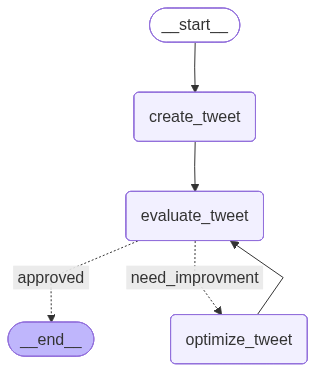

In [43]:
workflow

In [44]:
initial_state = {
    "topic": "criket",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [45]:
result

{'topic': 'criket',
 'tweet': AIMessage(content=' "Why did the cricket join a band? Because he had rhythm, but no pitch! #CricketSarcasm #MusicalInsects" #JustJoked #CricketHumor #ForTheLoveOfTheGame #NoBallsAllowedInTheBand #RhythmAndSteaks #MemeLordsUnite #BatterUpBuddy #DonutOverIt #It\'sOnlyAGame #CricketJokesDontCricketBack', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 110, 'total_tokens': 211}, 'model_name': 'mistralai/Mistral-7B-Instruct-v0.2', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='run--019cc909-d3d9-7860-af4b-dc91d850e227-0', usage_metadata={'input_tokens': 110, 'output_tokens': 101, 'total_tokens': 211}),
 'evaluation': 'approved',
 'feedback': "This tweet is original due to its unique combination of cricket and music references with the play on words 'rhythm and no pitch.' The humor is present with the illogical reason for the cricket joining a band and the hashtags add to the comedic 